In [103]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zlatan599/mushroom1")

print("Path to dataset files:", path)

Path to dataset files: /home/leo/.cache/kagglehub/datasets/zlatan599/mushroom1/versions/2


In [104]:
import pandas as pd
import os

train_df = pd.read_csv(os.path.join(path, "train.csv"))
test_df = pd.read_csv(os.path.join(path, "test.csv"))
val_df = pd.read_csv(os.path.join(path, "val.csv"))

print("Train DataFrame shape:", train_df.shape)
print("Test DataFrame shape:", test_df.shape)
print("Validation DataFrame shape:", val_df.shape)

print("Train DataFrame columns:", train_df.columns.tolist())
print("Test DataFrame columns:", test_df.columns.tolist())
print("Validation DataFrame columns:", val_df.columns.tolist())

Train DataFrame shape: (689520, 2)
Test DataFrame shape: (15614, 2)
Validation DataFrame shape: (15616, 2)
Train DataFrame columns: ['image_path', 'label']
Test DataFrame columns: ['image_path', 'label']
Validation DataFrame columns: ['image_path', 'label']


In [105]:
# correcting paths in dataframes
train_df['image_path'] = train_df["image_path"].apply(
    lambda p: os.path.join(path, "/".join(p.split("/")[-3:]))
)  
test_df['image_path'] = test_df["image_path"].apply(
    lambda p: os.path.join(path, "/".join(p.split("/")[-3:]))
)
val_df['image_path'] = val_df["image_path"].apply(
    lambda p: os.path.join(path, "/".join(p.split("/")[-3:]))
)

# checking if corrected paths exist
if os.path.exists(train_df['image_path'].iloc[0]):
    print("Corrected path exists.")
else:
    raise FileNotFoundError("Corrected image path does not exist.")

Corrected path exists.


In [106]:
import numpy as np

import matplotlib.pyplot as plt

# getting the labels from the training set
train_labels = train_df['label'].value_counts().index
test_labels = test_df['label'].value_counts().index
val_labels = val_df['label'].value_counts().index

print("There are ", len(train_labels), "unique labels in the training set.")
print("There are ", len(test_labels), "unique labels in the test set.")
print("There are ", len(val_labels), "unique labels in the validation set.")

# checking if all labels are the same across train, val, and test sets
if set(train_labels) == set(test_labels) == set(val_labels):
    print("All sets have the same labels.")
    labels = train_labels
else:
    raise ValueError("Labels differ between train, val, and test sets.")


There are  169 unique labels in the training set.
There are  169 unique labels in the test set.
There are  169 unique labels in the validation set.
All sets have the same labels.


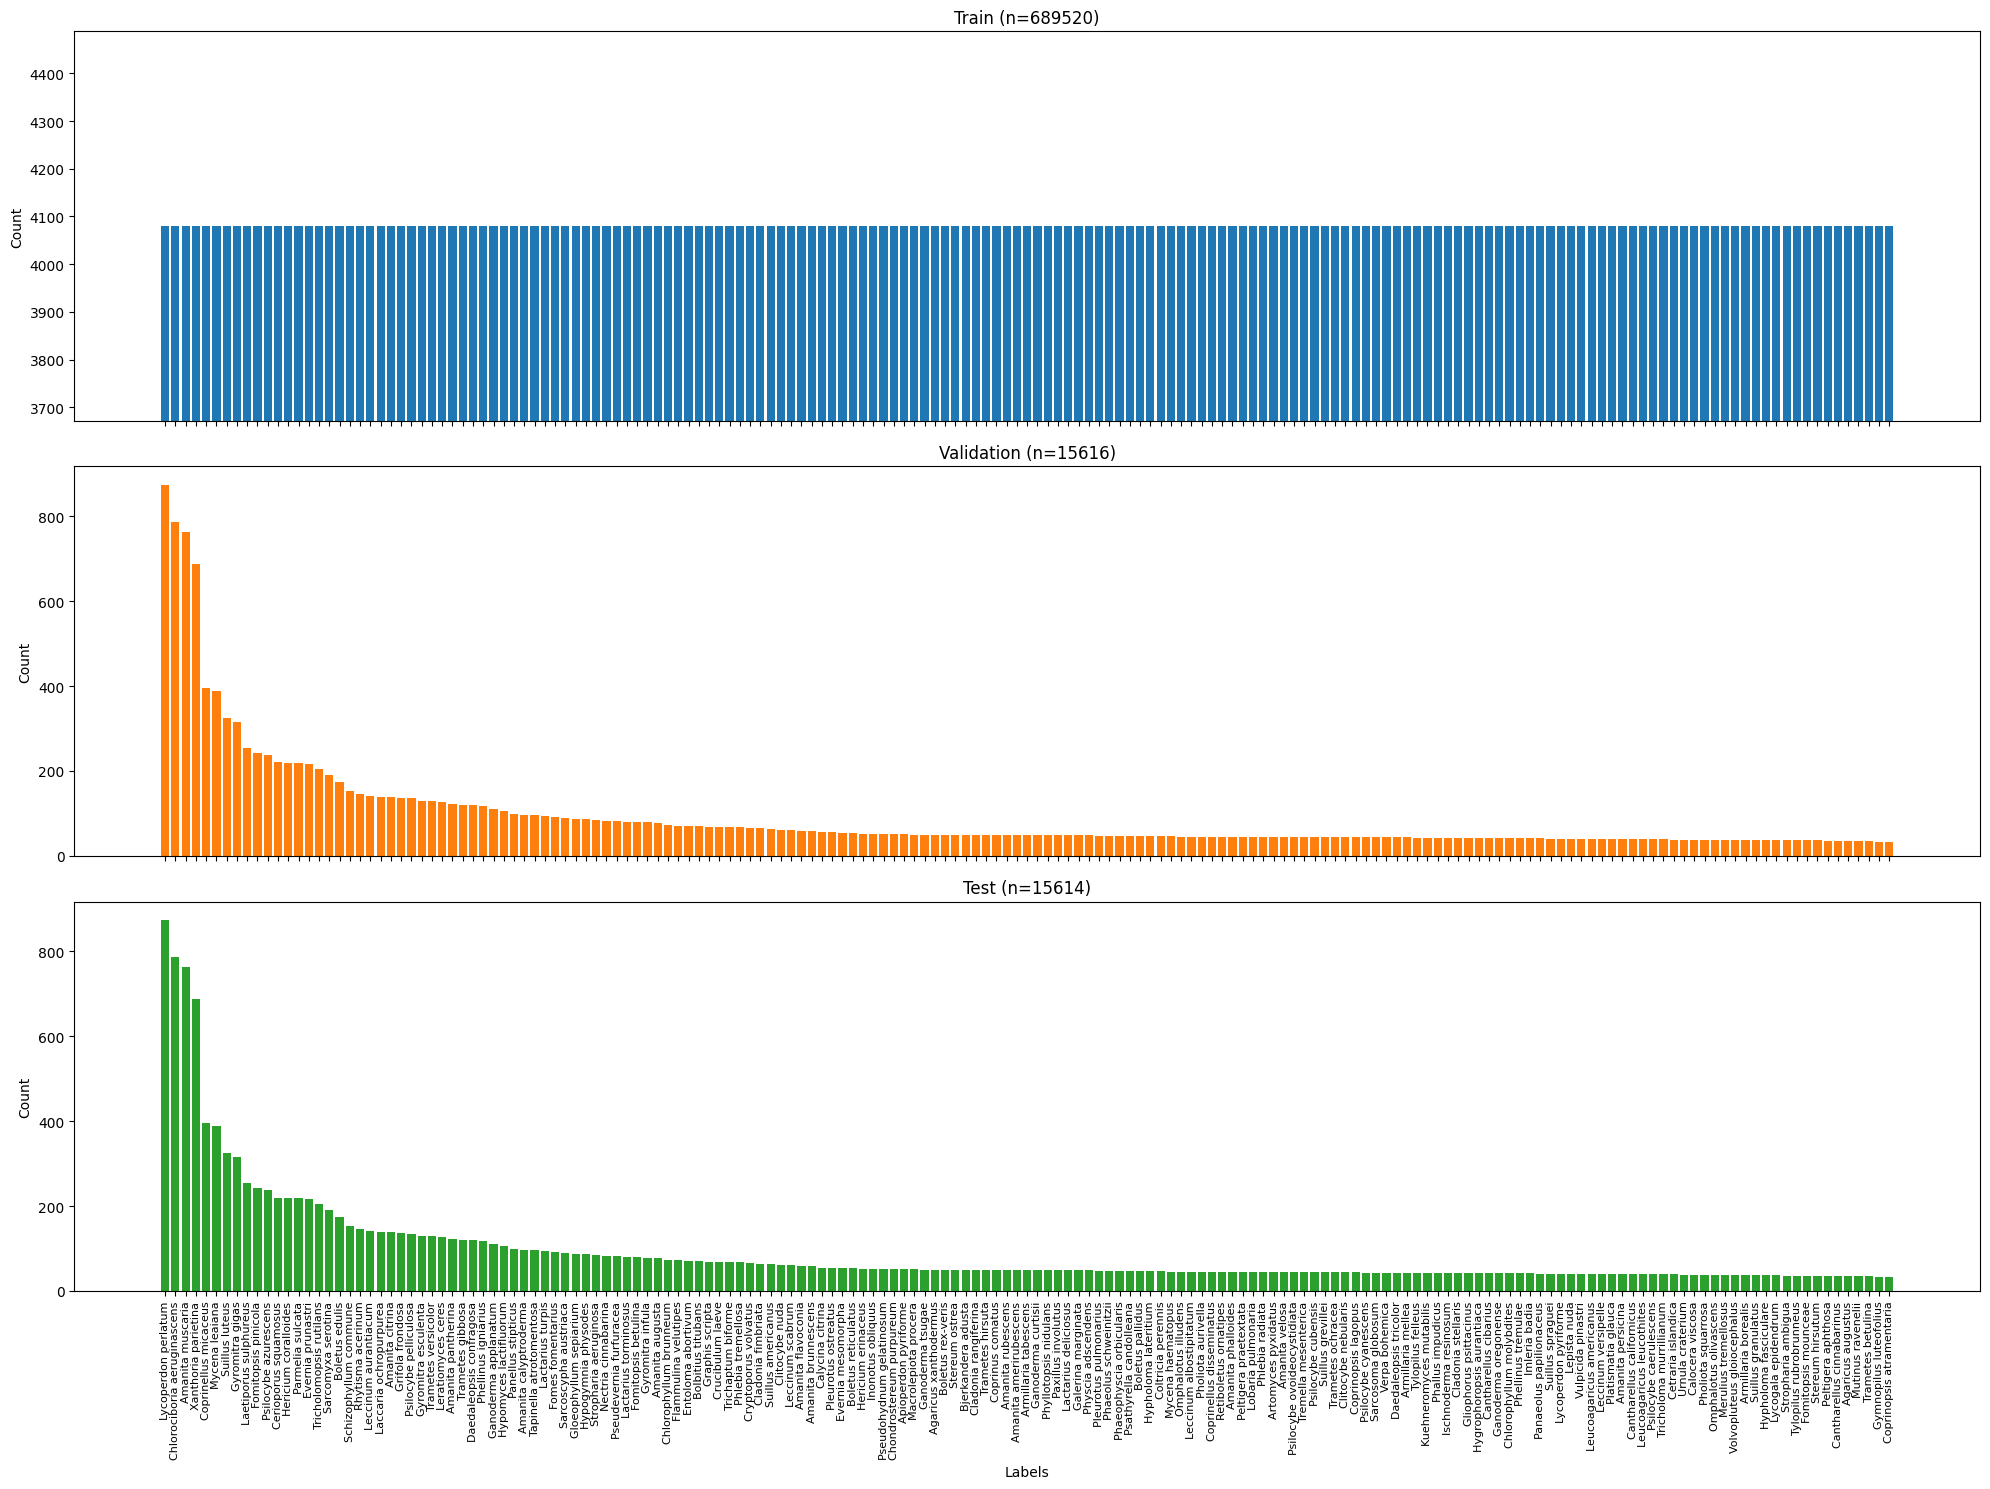

In [107]:
# calculating counts for each label in train, val, and test sets
counts_train = train_df['label'].value_counts()
counts_val = val_df['label'].value_counts()
counts_test = test_df['label'].value_counts()

x = np.arange(len(labels))

fig, axes = plt.subplots(3, 1, figsize=(20, 15), sharex=True)

axes[0].bar(x, counts_train, color='#1f77b4')
axes[0].set_title(f'Train (n={len(train_df)})')
axes[0].set_ylabel('Count')
# set y-limits for better visualization
axes[0].set_ylim(counts_train.min()*0.9, counts_train.max()*1.1)

axes[1].bar(x, counts_val, color='#ff7f0e')
axes[1].set_title(f'Validation (n={len(val_df)})')
axes[1].set_ylabel('Count')

axes[2].bar(x, counts_test, color='#2ca02c')
axes[2].set_title(f'Test (n={len(test_df)})')
axes[2].set_ylabel('Count')

# setting x-ticks and labels
plt.xticks(x, labels, rotation=90, fontsize=8)
plt.xlabel('Labels')
plt.tight_layout()
plt.show()

In [108]:
# saving the labels to a .csv file
# if the file already exists, it wont be overwritten
if os.path.exists('labels.csv'):
    print("labels.csv already exists. Not overwriting.")
else:
    labels_df = pd.DataFrame({'label': list(labels)})
    labels_df['edible'] = False
    labels_df.to_csv('labels.csv', index=False)
    print("labels.csv created.")

labels.csv already exists. Not overwriting.


In [109]:
# after manually adding the 'edible' column by searching online
# and automatically setting false if a species is a lichen or little to none information is found

labels_df = pd.read_csv('labels.csv')

# checking distribution and if there are any issues
counts = labels_df['edible'].value_counts()
print(counts)
print("Any missing label? ", any(labels_df['edible'].isnull()))

edible
False    93
True     76
Name: count, dtype: int64
Any missing label?  False


In train set: 44.97% edible and 55.03% non-edible
In validation set: 39.86% edible and 60.14% non-edible
In test set: 39.87% edible and 60.13% non-edible


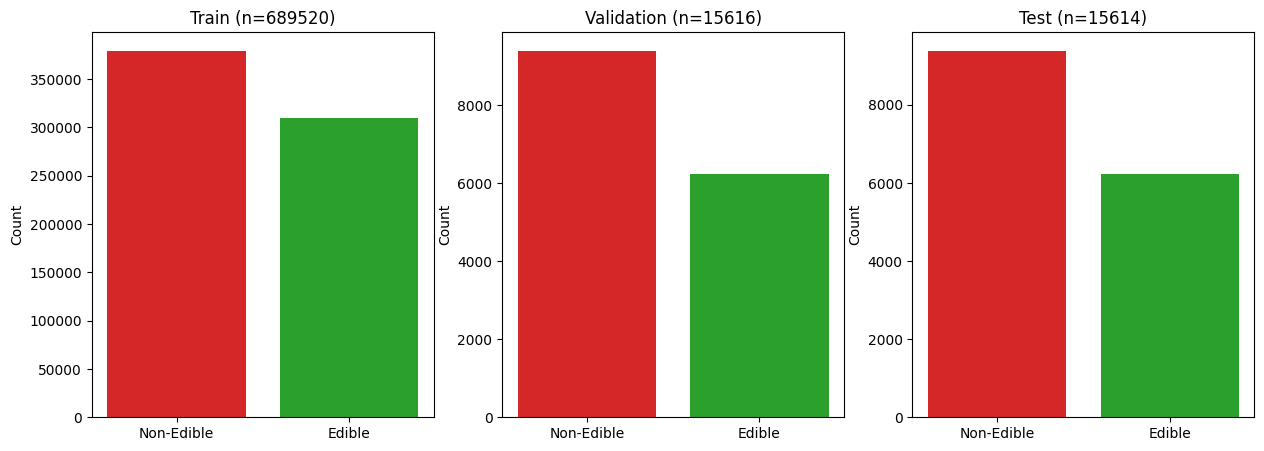

In [110]:
# merging the 'edible' information back to the main dataframes
if 'edible' in train_df.columns:
    print("'edible' column already exists in train_df. Skipping merge.")
else:
    train_df = pd.merge(train_df, labels_df, on='label', how='left')
    val_df = pd.merge(val_df, labels_df, on='label', how='left')
    test_df = pd.merge(test_df, labels_df, on='label', how='left')

# checking for any missing 'edible' values
if train_df['edible'].isnull().any():
    print(train_df.loc[train_df['edible'].isnull(), ['label', 'edible']])
    raise ValueError("Missing 'edible' values in training set after merge.")

edible_counts_train = train_df['edible'].value_counts()
edible_counts_val = val_df['edible'].value_counts()
edible_counts_test = test_df['edible'].value_counts()

# percentages
tmp = edible_counts_train.get(True, 0) / len(train_df) * 100
print(f'In train set: {tmp:.2f}% edible and {100 - tmp:.2f}% non-edible')
tmp = edible_counts_val.get(True, 0) / len(val_df) * 100
print(f'In validation set: {tmp:.2f}% edible and {100 - tmp:.2f}% non-edible')
tmp = edible_counts_test.get(True, 0) / len(test_df) * 100
print(f'In test set: {tmp:.2f}% edible and {100 - tmp:.2f}% non-edible')

# show plot of edible vs non-edible in sets
labels = ['Non-Edible', 'Edible']
x = np.arange(len(labels))
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)
axes[0].bar(x, [edible_counts_train.get(False, 0), edible_counts_train.get(True, 0)], color=['#d62728', '#2ca02c'])
axes[0].set_title(f'Train (n={len(train_df)})')
axes[0].set_ylabel('Count')
axes[1].bar(x, [edible_counts_val.get(False, 0), edible_counts_val.get(True, 0)], color=['#d62728', '#2ca02c'])
axes[1].set_title(f'Validation (n={len(val_df)})')
axes[1].set_ylabel('Count')
axes[2].bar(x, [edible_counts_test.get(False, 0), edible_counts_test.get(True, 0)], color=['#d62728', '#2ca02c'])
axes[2].set_title(f'Test (n={len(test_df)})')
axes[2].set_ylabel('Count')
plt.xticks(x, labels)
plt.show()


In [ ]:
# dropping 90% of the training set images to speed up experiments
# mantaining class distribution but with only 200 random samples per mushroom species

sample_size_per_class = 200

train_df_reduced = (
    train_df.sample(frac=1, random_state=42)   # shuffle rows
            .groupby('label', group_keys=False)
            .head(sample_size_per_class)
            .reset_index(drop=True)
)
print("Reduced Train DataFrame shape:", train_df_reduced.shape)

Reduced Train DataFrame shape: (33800, 3)


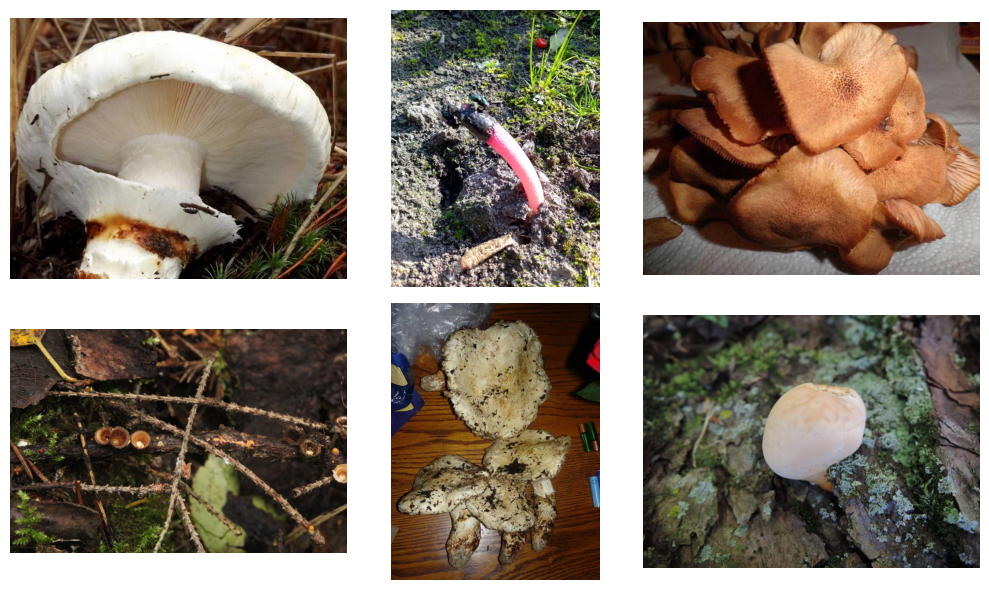

In [112]:

# correcting paths for reduced dataframe
train_df_reduced['image_path'] = train_df_reduced['image_path'].apply(
    lambda p: os.path.join(path, p)
)

# randomly display some images from the training set
import random
random.seed(42)
# Multiple of 3 for better visualization
samples = 6
indicies = random.sample(range(len(train_df_reduced)), samples)
images_paths = train_df_reduced.iloc[indicies]['image_path'].values

images = []
for img_path in images_paths:
    img = plt.imread(img_path)
    images.append(img)

fig, axes = plt.subplots(samples // 3, 3, figsize=(10, 3 * (samples // 3)))
for i, ax in enumerate(axes.flatten()):
    if i < samples:
        ax.imshow(images[i])
    ax.axis('off')
plt.tight_layout()
plt.show()

image_sizes.csv already exists. Not overwriting.
Unique sizes:  1075
Any missing sizes?  False


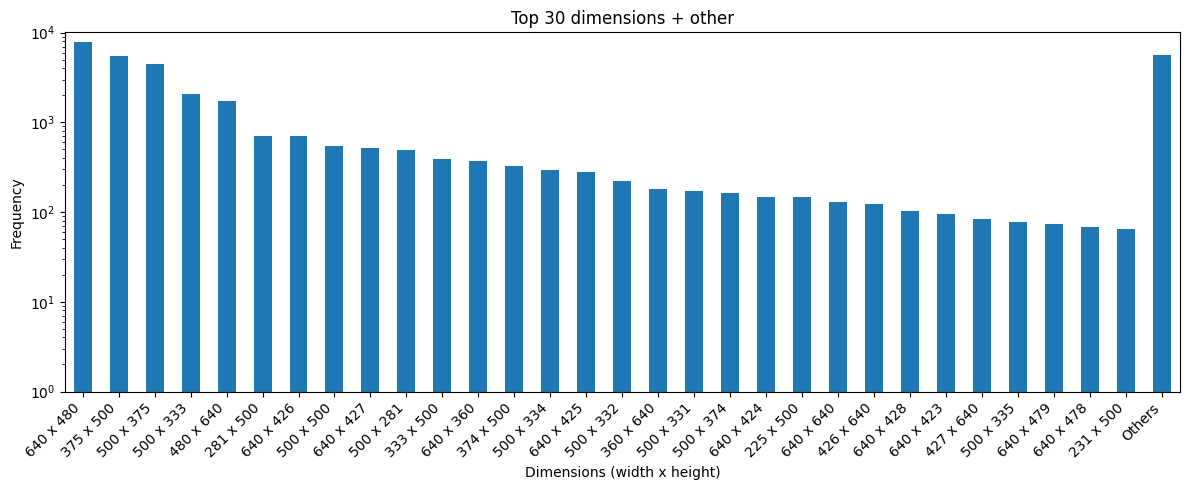

In [113]:
from concurrent.futures import ProcessPoolExecutor
import matplotlib.pyplot as plt

def get_image_size(img_path):
    try:
        img = plt.imread(img_path)
        h, w = img.shape[:2]
        return {'width': w, 'height': h}
    except Exception as e:
        print(f"Error with {img_path}: {e}")
        return None

if os.path.exists('image_sizes.csv'):
    print("image_sizes.csv already exists. Not overwriting.") 
    unique_sizes = pd.read_csv('image_sizes.csv', index_col=0)
else:
    image_paths = train_df_reduced['image_path'].tolist()

    # parallel processing to get image sizes for training set images
    with ProcessPoolExecutor(max_workers=8) as executor:
        sizes_list = list(executor.map(get_image_size, image_paths))

    sizes = pd.DataFrame(sizes_list)

    # getting 'width - height' combinations
    sizes['width_height'] = sizes['width'].astype(str) + " x " + sizes['height'].astype(str)
    unique_sizes = (
            sizes['width_height']
            .value_counts()
            .rename("count")        # name of the column
            .to_frame()             # convert Series to DataFrame
        )
    # saving unique sizes to a CSV file
    unique_sizes.to_csv('image_sizes.csv', index=True)

print("Unique sizes: ", len(unique_sizes))
print("Any missing sizes? ", unique_sizes.isnull().any().any())

# calculating 'other' row
top_n = 30
top_sizes = unique_sizes['count'].head(top_n)
other_sizes_count = unique_sizes['count'].iloc[top_n:].sum()

other_series = pd.Series({'Others': other_sizes_count})
top_sizes = pd.concat([top_sizes, other_series])

# plotting the distribution of image sizes
fig, ax = plt.subplots(figsize=(12, 5))
top_sizes.plot(kind='bar', ax=ax, color='#1f77b4')
ax.set_title(f'Top {top_n} dimensions + other')
ax.set_xlabel('Dimensions (width x height)')
ax.set_ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
ax.set_yscale('log')
ax.set_ylim(bottom=1)
plt.tight_layout()
plt.show()

In [115]:
from torch.utils.data import Dataset
from torchvision import transforms

class MushroomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['edible']
        
        # ensure image is loaded in RGB mode
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

# all the torchvision models expect 3-channel images of size at least 224x224
# we resize the images to 224x224 and normalize them using ImageNet statistics
image_size = 224
basic_transform = transforms.Compose([
    # resize shorter side to 256
    transforms.Resize(256),
    # crop to 224x224 to match model input size without distorting aspect ratio
    transforms.CenterCrop(224), 
    # convert to tensor and normalize
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# creating dataset instances
train_dataset = MushroomDataset(train_df_reduced, transform=train_transform)
val_dataset = MushroomDataset(val_df, transform=basic_transform)
test_dataset = MushroomDataset(test_df, transform=basic_transform)
print("Dataset instances created successfully.")

Dataset instances created successfully.


In [116]:
# defining model
import torch
import torchvision.models as models

# modifying the final layer, the third block, for binary classification
weights = models.MobileNet_V3_Small_Weights.DEFAULT
model = models.mobilenet_v3_small(weights=weights)
print("Classifier layer:", model.classifier[3])
model.classifier[3] = torch.nn.Linear(model.classifier[3].in_features, 1)
print("Modified Classifier layer:", model.classifier[3])
print("The model input size is:", model.classifier[0].in_features)

# checking model parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

# transferring model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Model transferred to device: {device}")


Classifier layer: Linear(in_features=1024, out_features=1000, bias=True)
Modified Classifier layer: Linear(in_features=1024, out_features=1, bias=True)
The model input size is: 576
Total parameters: 1518881
Model transferred to device: cuda


In [ ]:
# defining dataloaders
from torch.utils.data import DataLoader
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

print(f"Train loader batches: {len(train_loader)}")
print(f"Validation loader batches: {len(val_loader)}")
print(f"Test loader batches: {len(test_loader)}")

Train loader batches: 1057
Validation loader batches: 488
Test loader batches: 488


In [118]:
# defining the metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
train_loss_list = []
val_loss_list = []
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []
confusion_matrices = []

# training setup
import torch.optim as optim
import tqdm

# calculating pos_weight for BCEWithLogitsLoss (value > 1)
edible_counts_train_reduced = train_df_reduced['edible'].value_counts()
pos_weight = edible_counts_train_reduced.get(False, 0) / edible_counts_train_reduced.get(True, 1)
print(f"Class weight (edible): {pos_weight:.2f}")

# defining loss function and optimizer
num_epochs = 5
lr = 2e-4
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

Class weight (edible): 1.22


In [119]:
# defining validation testing function
def evaluate_model(model, dataloader, device):
    model.eval()
    all_labels = []
    all_preds = []
    val_loss = 0.0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)
            outputs = model(inputs)

            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = torch.sigmoid(outputs).cpu().numpy() > 0.5 
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.astype(int).flatten())
    
    val_loss /= len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    # why the model should not predict any class??
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    # tp, fp, tn, fn
    cm = confusion_matrix(all_labels, all_preds)
    
    return val_loss, accuracy, precision, recall, f1, cm

In [120]:
# freeing GPU memory before training
torch.cuda.empty_cache()

if os.path.exists('best_val_loss.txt'):
    with open('best_val_loss.txt', 'r') as f:
        best_val_loss = float(f.read().strip())
    print(f"Loaded best validation loss from file: {best_val_loss:.4f}")
else:
    best_val_loss = float('inf')
model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    loop = tqdm.tqdm(train_loader, leave=True, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")
    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device)
        # BCEWithLogitsLoss expects float targets of shape (N, 1)
        labels = labels.float().unsqueeze(1) 
        # training step
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # evaluate on validation set
    val_loss, accuracy, precision, recall, f1, cm = evaluate_model(model, val_loader, device)
    # saving and printing
    epoch_loss = running_loss / len(train_loader)
    train_loss_list.append(epoch_loss)
    val_loss_list.append(val_loss)
    accuracy_list.append(accuracy)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)
    confusion_matrices.append(cm) 

    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {epoch_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Acc: {accuracy:.4f} | "
          f"F1: {f1:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    if val_loss < best_val_loss:
        # saving the best model and best val loss to a file
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        with open('best_val_loss.txt', 'w') as f:
            f.write(f"{best_val_loss:.4f}")
        print(f"Best model saved with validation loss: {best_val_loss:.4f}")

Epoch 1/5: 100%|██████████| 1057/1057 [00:33<00:00, 32.01batch/s]


Epoch 1/5 | Train Loss: 0.5990 | Val Loss: 0.4745 | Acc: 0.7900 | F1: 0.7227 | LR: 0.000200
Best model saved with validation loss: 0.4745


Epoch 2/5: 100%|██████████| 1057/1057 [00:32<00:00, 32.77batch/s]


Epoch 2/5 | Train Loss: 0.5376 | Val Loss: 0.4602 | Acc: 0.7907 | F1: 0.7493 | LR: 0.000200
Best model saved with validation loss: 0.4602


Epoch 3/5: 100%|██████████| 1057/1057 [00:32<00:00, 32.68batch/s]


Epoch 3/5 | Train Loss: 0.4597 | Val Loss: 0.4484 | Acc: 0.8030 | F1: 0.7716 | LR: 0.000200
Best model saved with validation loss: 0.4484


Epoch 4/5: 100%|██████████| 1057/1057 [00:32<00:00, 32.75batch/s]


Epoch 4/5 | Train Loss: 0.4067 | Val Loss: 0.4291 | Acc: 0.8126 | F1: 0.7806 | LR: 0.000200
Best model saved with validation loss: 0.4291


Epoch 5/5: 100%|██████████| 1057/1057 [00:32<00:00, 32.34batch/s]


Epoch 5/5 | Train Loss: 0.3609 | Val Loss: 0.4065 | Acc: 0.8352 | F1: 0.7968 | LR: 0.000200
Best model saved with validation loss: 0.4065


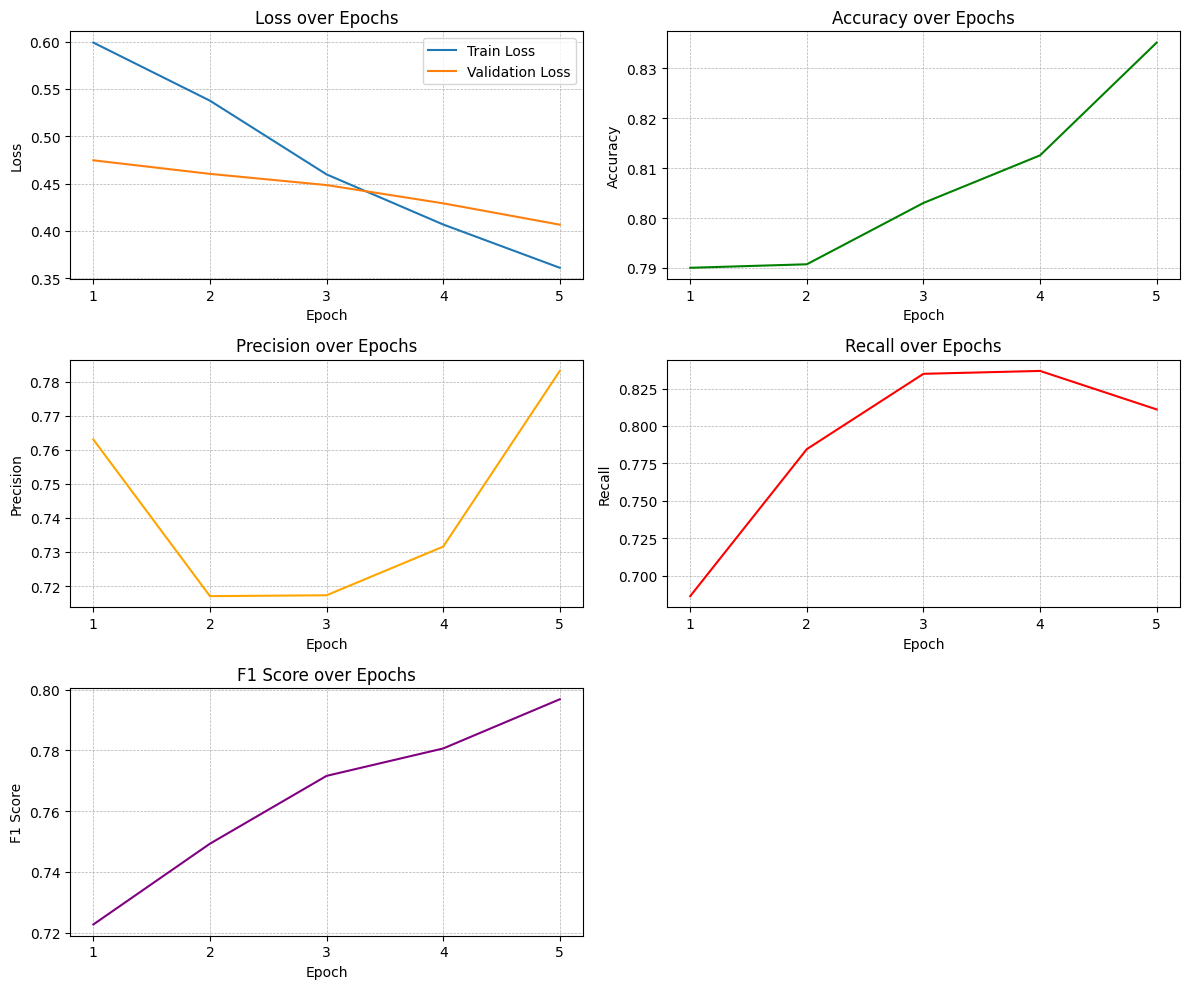

In [141]:
epochs_range = range(1, num_epochs + 1)

fig, ax = plt.subplots(3, 2, figsize=(12, 10))

# Loss
ax[0, 0].plot(epochs_range, train_loss_list, label='Train Loss')
ax[0, 0].plot(epochs_range, val_loss_list, label='Validation Loss')
ax[0, 0].set_title('Loss over Epochs')
ax[0, 0].set_xlabel('Epoch')
ax[0, 0].set_ylabel('Loss')
ax[0, 0].legend()
ax[0, 0].set_xticks(epochs_range)
ax[0, 0].grid(visible=True, axis='both', which='both', linestyle='--', linewidth=0.5)

# Accuracy
ax[0, 1].plot(epochs_range, accuracy_list, label='Accuracy', color='g')
ax[0, 1].set_title('Accuracy over Epochs')
ax[0, 1].set_xlabel('Epoch')
ax[0, 1].set_ylabel('Accuracy')
ax[0, 1].set_xticks(epochs_range)
ax[0, 1].grid(visible=True, axis='both', which='both', linestyle='--', linewidth=0.5)

# Precision
ax[1, 0].plot(epochs_range, precision_list, label='Precision', color='orange')
ax[1, 0].set_title('Precision over Epochs')
ax[1, 0].set_xlabel('Epoch')
ax[1, 0].set_ylabel('Precision')
ax[1, 0].set_xticks(epochs_range)
ax[1, 0].grid(visible=True, axis='both', which='both', linestyle='--', linewidth=0.5)

# Recall
ax[1, 1].plot(epochs_range, recall_list, label='Recall', color='red')
ax[1, 1].set_title('Recall over Epochs')
ax[1, 1].set_xlabel('Epoch')
ax[1, 1].set_ylabel('Recall')
ax[1, 1].set_xticks(epochs_range)
ax[1, 1].grid(visible=True, axis='both', which='both', linestyle='--', linewidth=0.5)

# F1 Score
ax[2, 0].plot(epochs_range, f1_list, label='F1 Score', color='purple')
ax[2, 0].set_title('F1 Score over Epochs')
ax[2, 0].set_xlabel('Epoch')
ax[2, 0].set_ylabel('F1 Score')
ax[2, 0].set_xticks(epochs_range)
ax[2, 0].grid(visible=True, axis='both', which='both', linestyle='--', linewidth=0.5)

ax[2, 1].axis('off')  # empty subplot
plt.tight_layout()
plt.show()

In [142]:
# loading the best model
model.load_state_dict(torch.load('best_model.pth'))
print("Best model loaded for testing.")

# printing evaluation metrics on the test set
test_loss, acc, prec, rec, f1, cm = evaluate_model(model, test_loader, device)
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print("Confusion Matrix:\n", cm)

Best model loaded for testing.
Accuracy: 0.8283
Precision: 0.7783
Recall: 0.7961
F1-Score: 0.7871
Confusion Matrix:
 [[7977 1412]
 [1269 4956]]
